# 1. PROBLEM STATEMENT
Title:
Loan Default Prediction using Machine Learning and Data-Driven Feature Analysis

Abstract (Short):
This study aims to predict the likelihood of loan default using structured financial and demographic data. By combining statistical analysis, feature engineering, and baseline machine learning models, we establish a benchmark for subsequent deep learning experimentation.

Problem Definition:
Loan default prediction is a binary classification task where the objective is to classify applicants into default (1) or non-default (0) categories based on input features.

Hypothesis:

Proper handling of missing values, feature scaling, and selection of informative variables will significantly improve classification performance compared to naive baseline models.

# 2. DATA LOADING + OVERVIEW

In [96]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

df = pd.read_csv(r"D:\loan-default-prediction\data\raw\application_train.csv")

df.shape
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 325.2 MB


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [8]:
df.isnull().sum().sum()

np.int64(9152465)

Missing Value Summary
The dataset contains ~9.15 million missing values
Missing data is not sparse, it is structurally significant
Many features likely have high missing percentages
Proper handling of missing values is critical for model performance

# 2. FEATURE CATEGORIZATION

In [9]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

len(num_cols), len(cat_cols)

C:\Users\sanke\AppData\Local\Temp\ipykernel_13896\3173179061.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


(106, 16)

# 3. TARGET VARIABLE ANALYSIS

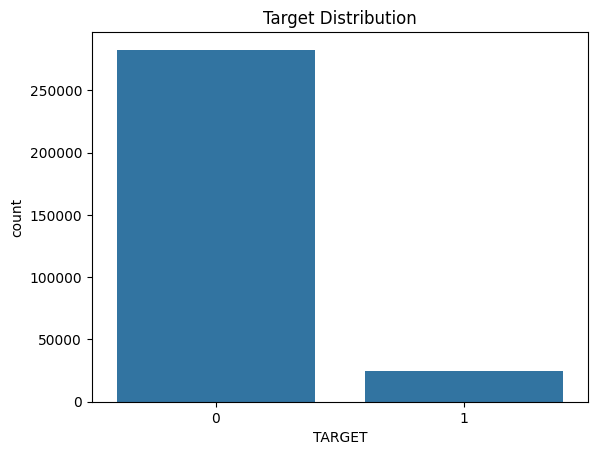

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

In [10]:
sns.countplot(x='TARGET', data=df)
plt.title("Target Distribution")
plt.show()

df['TARGET'].value_counts(normalize=True)

# 4. MISSING VALUE ANALYSIS

In [11]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

missing_df.head(20)

,Missing Count,Missing %
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


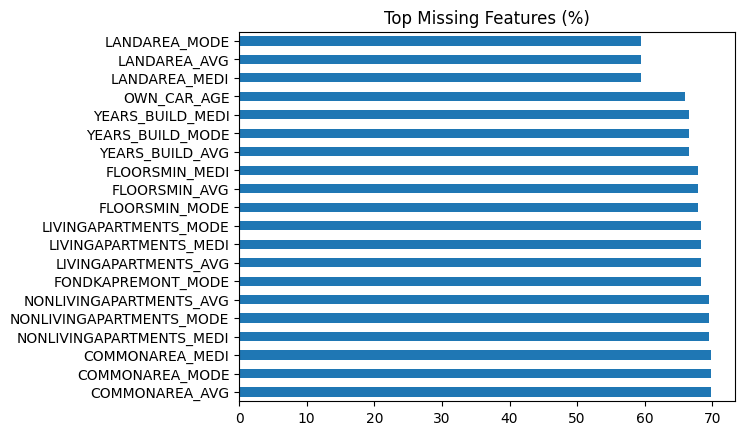

In [12]:
missing_df[missing_df['Missing %'] > 0]['Missing %'][:20].plot(kind='barh')
plt.title("Top Missing Features (%)")
plt.show()

# 5. NUMERICAL FEATURE ANALYSIS

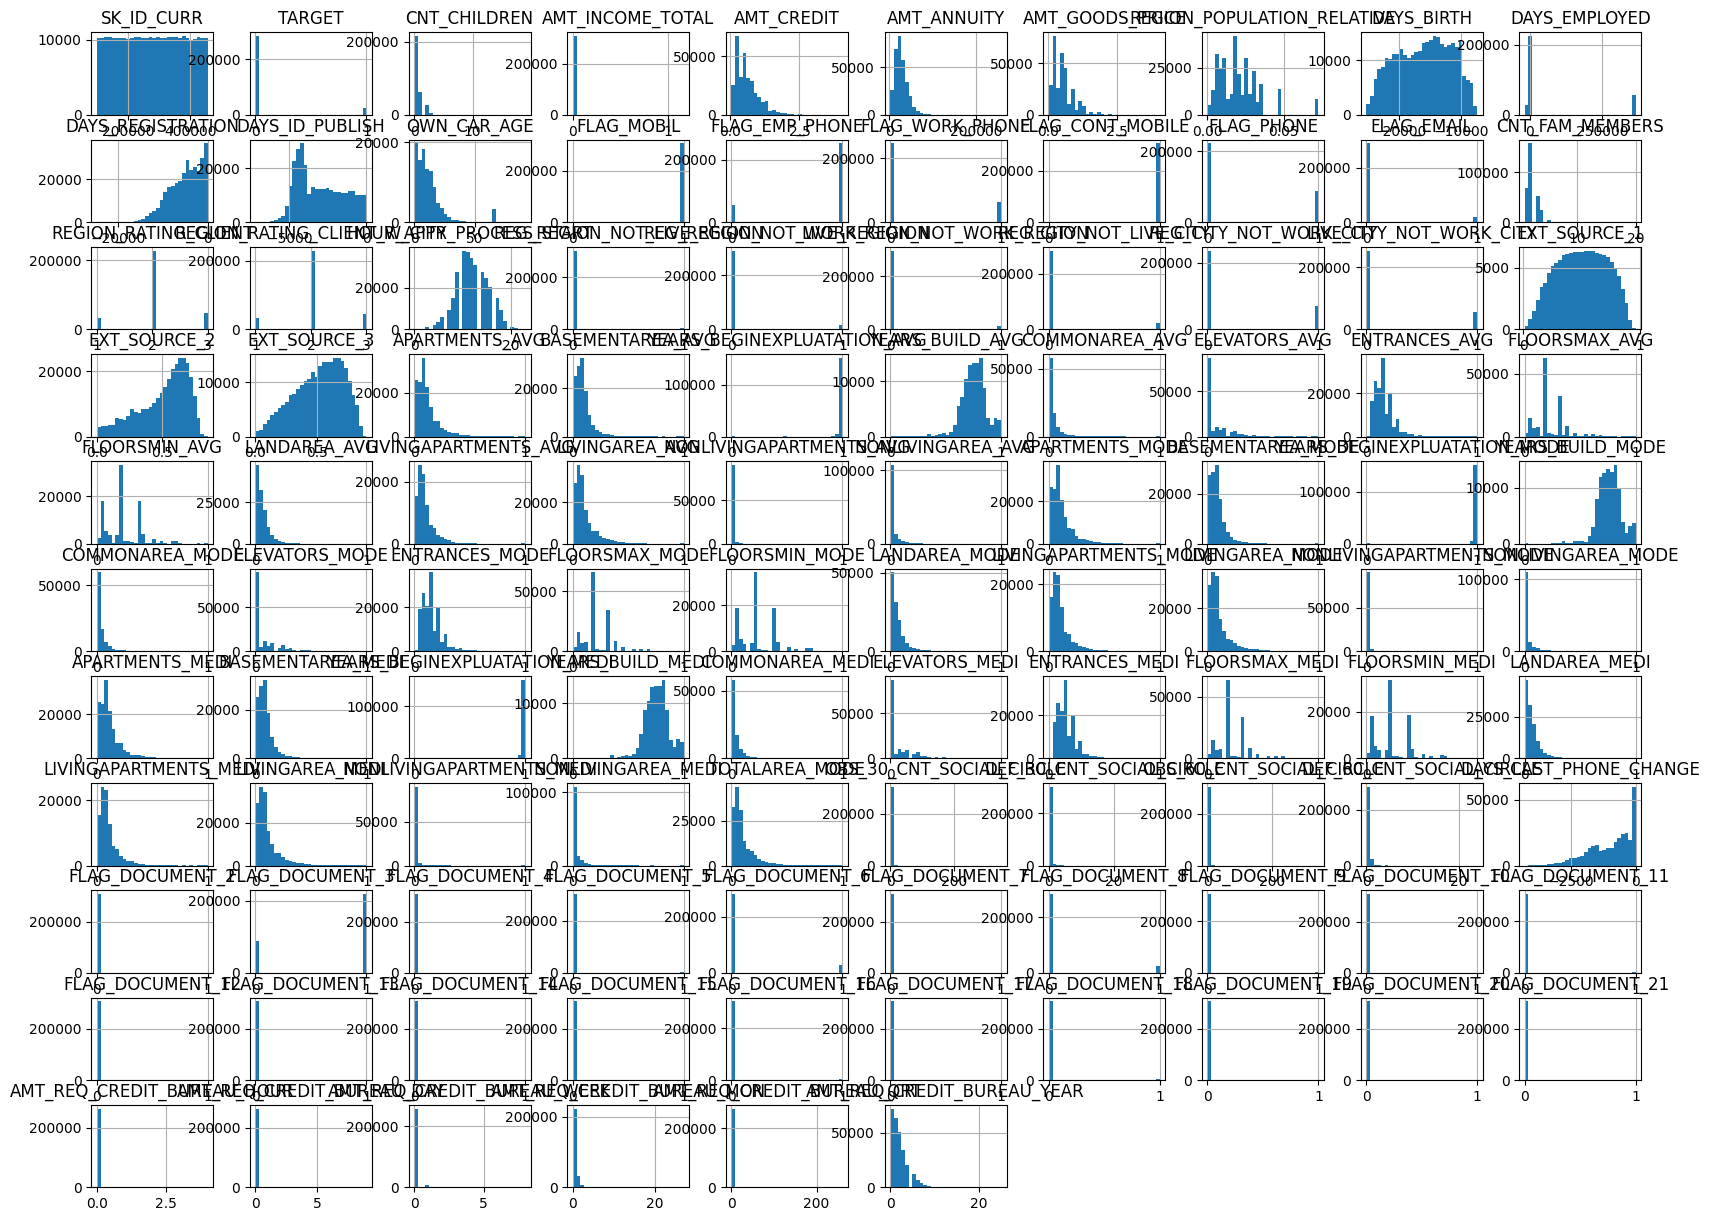

In [13]:
#5.1 Distribution
df[num_cols].hist(figsize=(20,15), bins=30)
plt.show()

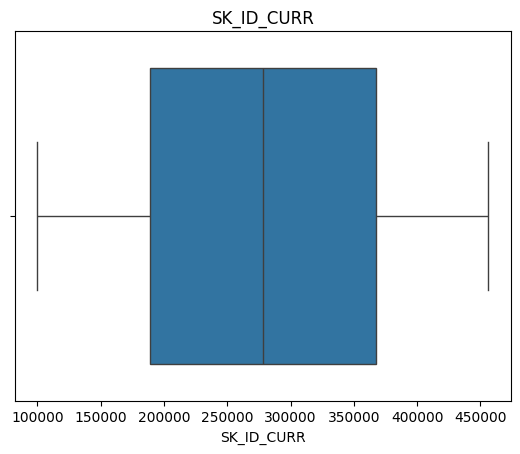

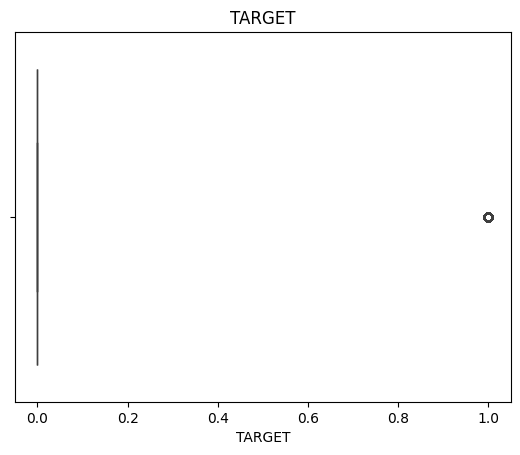

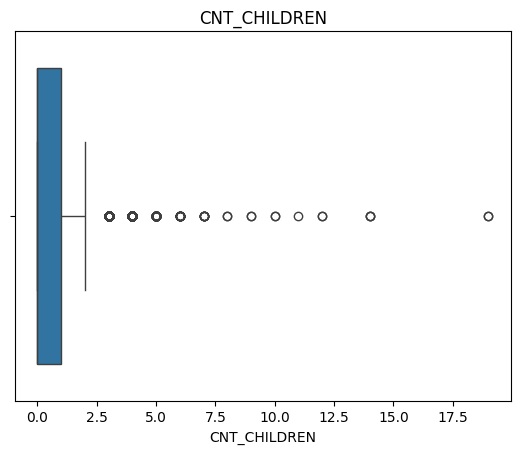

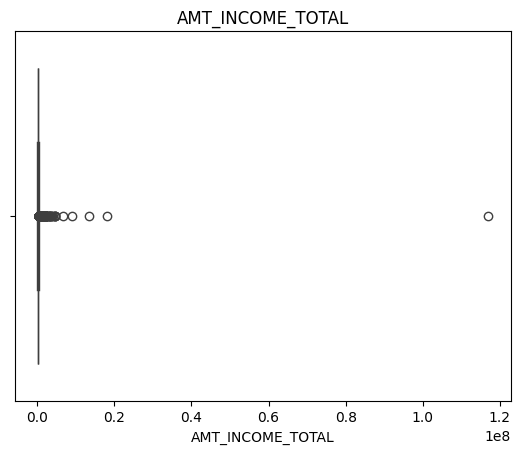

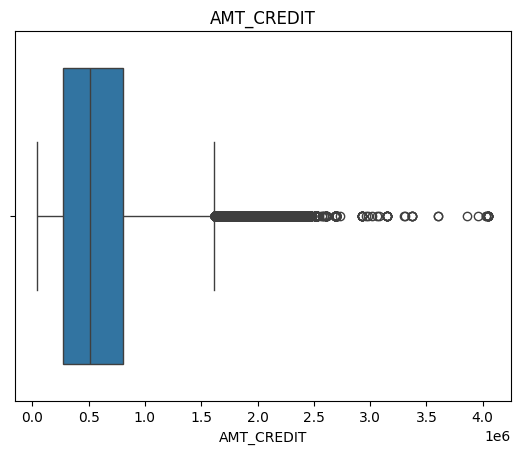

In [14]:
#5.2 Outlier Detection
for col in num_cols[:5]:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# 6. CORRELATION ANALYSIS

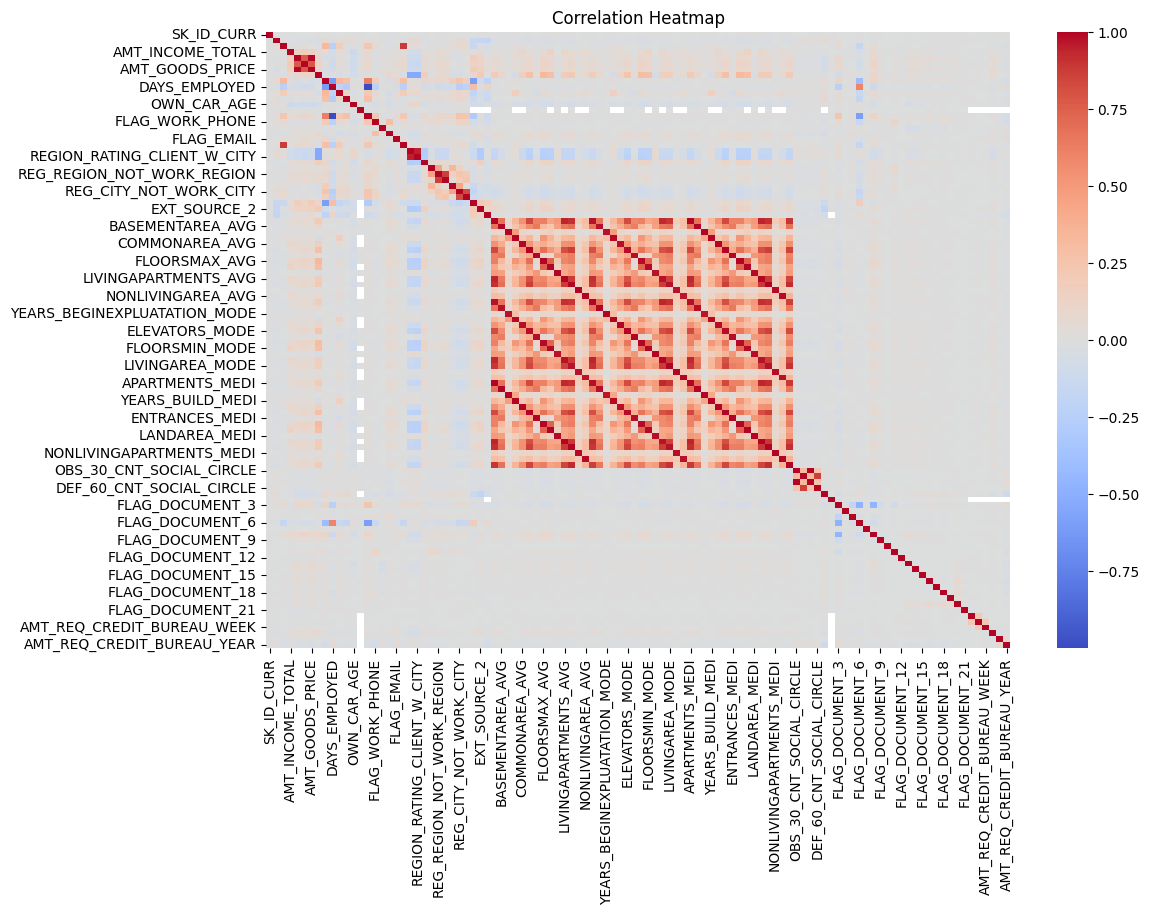

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# 7. FEATURE vs TARGET ANALYSIS

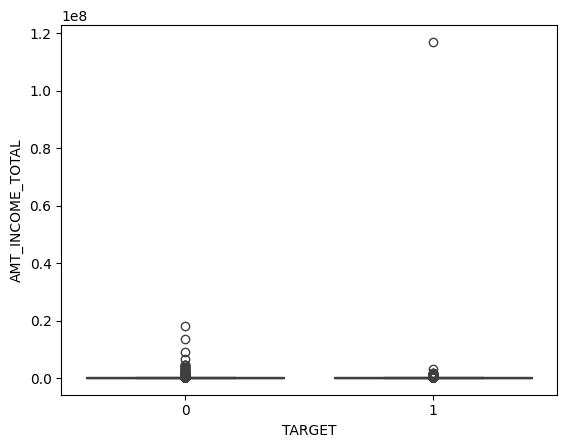

In [16]:
#Income vs Target
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=df)
plt.show()

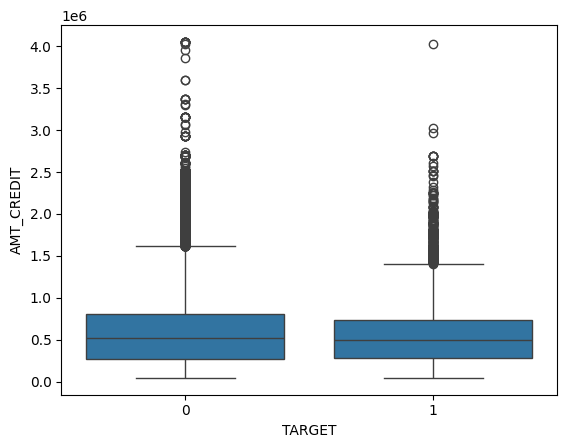

In [17]:
#Credit vs Target
sns.boxplot(x='TARGET', y='AMT_CREDIT', data=df)
plt.show()

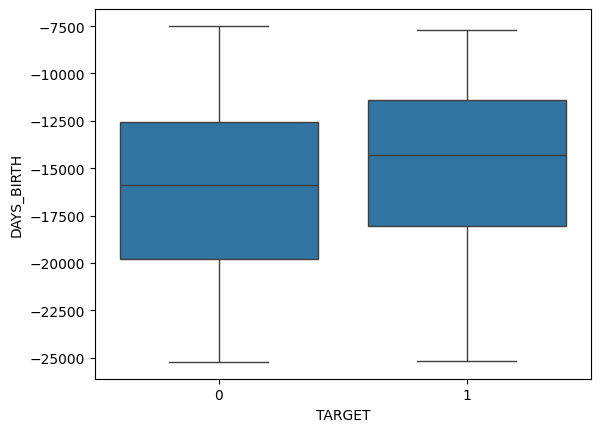

In [18]:
#Age vs Target
sns.boxplot(x='TARGET', y='DAYS_BIRTH', data=df)
plt.show()

# 8. CATEGORICAL FEATURE ANALYSIS

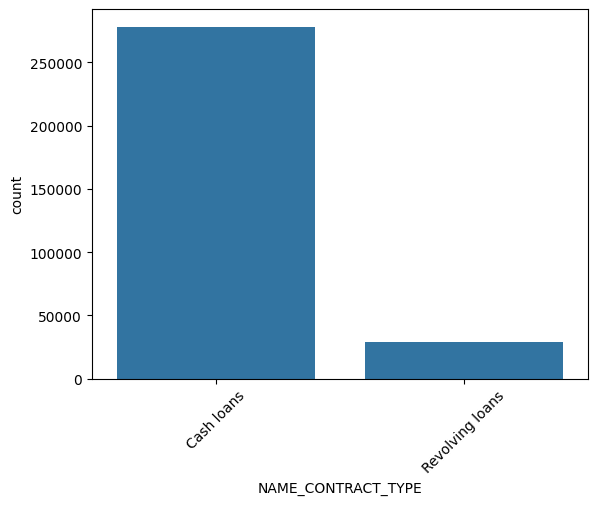

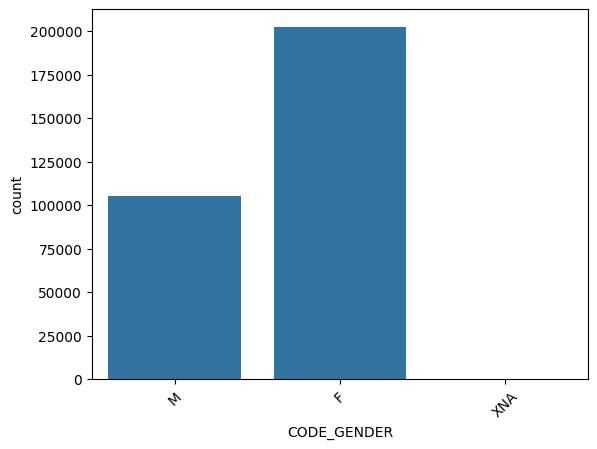

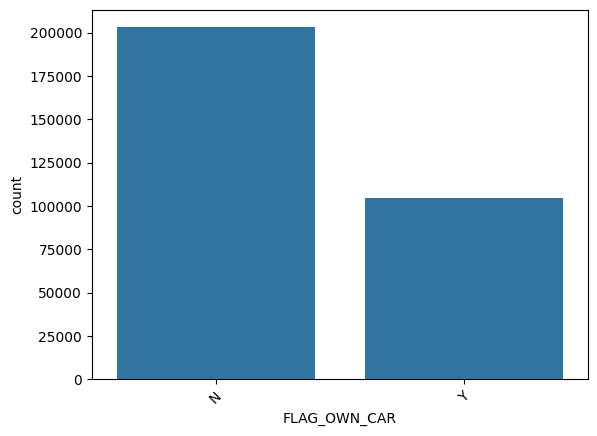

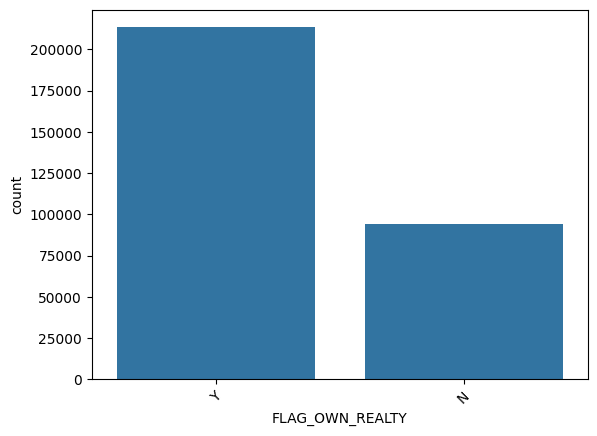

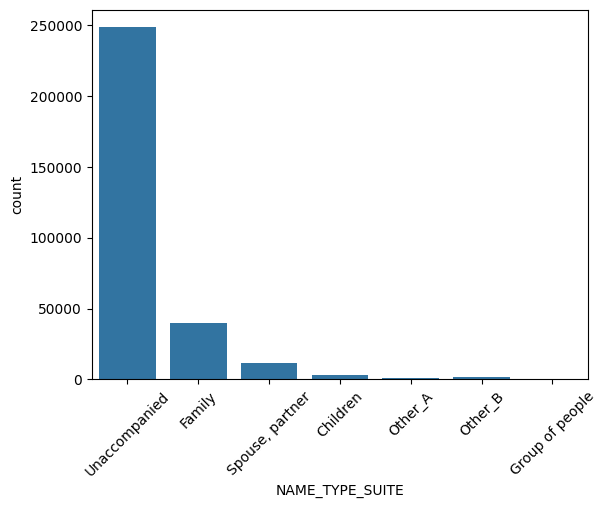

In [19]:
for col in cat_cols[:5]:
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.show()

# PREPROCESSING + BASELINE MODEL

In [20]:
#Select Target & Features
X = df.drop(columns=['TARGET'])
y = df['TARGET']

In [21]:
#Train/Test Split 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
#Separate Numerical & Categorical
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

C:\Users\sanke\AppData\Local\Temp\ipykernel_13896\4173278529.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns


In [23]:
#Preprocessing Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [24]:
#Numerical pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [25]:
#Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

In [26]:
#Combine
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [30]:
#Train Model
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [31]:
#Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [32]:
#Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
roc  = roc_auc_score(y_test, y_prob)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)
print("ROC AUC  :", roc)

Accuracy : 0.9194673430564363
Precision: 0.5535714285714286
Recall   : 0.012487411883182276
F1 Score : 0.02442387236557022
ROC AUC  : 0.7484137628011026


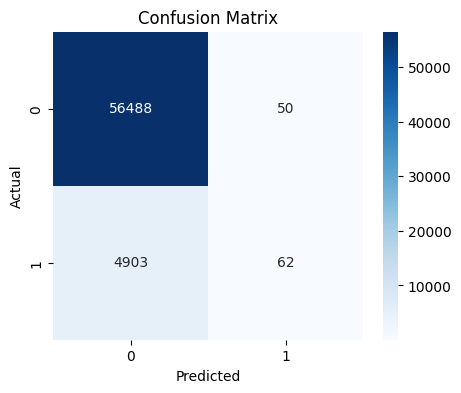

In [33]:
#Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [34]:
#Classification Report 
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.55      0.01      0.02      4965

    accuracy                           0.92     61503
   macro avg       0.74      0.51      0.49     61503
weighted avg       0.89      0.92      0.88     61503



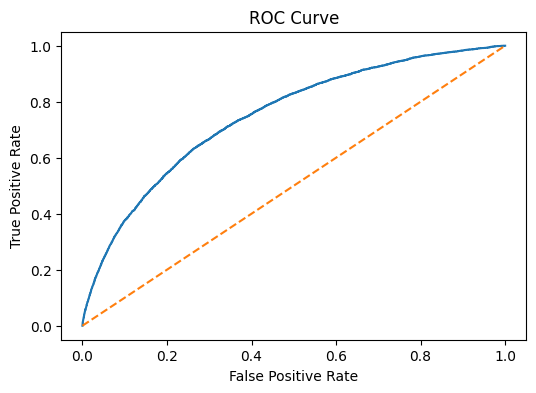

In [35]:
#ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [36]:
#Benchmark Table
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [acc],
    "Precision": [prec],
    "Recall": [rec],
    "F1 Score": [f1],
    "ROC AUC": [roc]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.919467,0.553571,0.012487,0.024424,0.748414


In [37]:
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [round(acc, 4)],
    "Precision": [round(prec, 4)],
    "Recall": [round(rec, 4)],
    "F1 Score": [round(f1, 4)],
    "ROC AUC": [round(roc, 4)]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9195,0.5536,0.0125,0.0244,0.7484


In [38]:
results.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}",
    "ROC AUC": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9195,0.5536,0.0125,0.0244,0.7484


The baseline Logistic Regression model achieves high accuracy, primarily due to class imbalance.
Precision and recall provide a more meaningful evaluation of model performance.
Recall is particularly important in this problem, as failing to identify defaulters can lead to financial risk.
The current baseline shows limitations in capturing minority class instances.

# WEEK-2 

#  1 — BASE ARCHITECTURE

In [ ]:
def build_model(input_dim, activation='relu', optimizer='adam', dropout=False):
    from tensorflow import keras
    from tensorflow.keras import layers
    
    model = keras.Sequential()
    
    #  Proper input layer (the fix)
    model.add(keras.Input(shape=(input_dim,)))
    
    model.add(layers.Dense(128, activation=activation))
    
    if dropout:
        model.add(layers.Dropout(0.3))
    
    model.add(layers.Dense(64, activation=activation))
    model.add(layers.Dense(1, activation='sigmoid'))
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [82]:
input_dim = X_train.shape[1]
model = build_model(input_dim)

# 2 — SECOND ARCHITECTURE

In [ ]:
def build_model_deep(input_dim):
    from tensorflow import keras
    from tensorflow.keras import layers
    
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),   #  proper entry point
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# EXPERIMENT 2: ACTIVATION FUNCTION

In [84]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [85]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'string']).columns

In [86]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [87]:
#Numerical pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [88]:
#Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [89]:
#Create Preprocessor
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [90]:
#Transform Data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [91]:
print(type(preprocessor))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [92]:
#Define Input Dimension
input_dim = X_train_processed.shape[1]
print(input_dim)

245


In [93]:
model = build_model(input_dim, activation='relu')

In [97]:
model = build_model(input_dim, activation=tf.keras.layers.LeakyReLU())

# EXPERIMENT 3: OPTIMIZER

In [98]:
model = build_model(input_dim, optimizer='adam')

In [99]:
model = build_model(input_dim, optimizer='sgd')

# EXPERIMENT 4: DROPOUT

In [100]:
model = build_model(input_dim, dropout=False)

In [101]:
model = build_model(input_dim, dropout=True)

# EXPERIMENT 5: BATCH SIZE

In [102]:
model.fit(
    X_train_processed, 
    y_train,
    validation_data=(X_test_processed, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
7688/7688 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9192 - loss: 0.2585 - val_accuracy: 0.9192 - val_loss: 0.2522
Epoch 2/10
7688/7688 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - accuracy: 0.9192 - loss: 0.2535 - val_accuracy: 0.9193 - val_loss: 0.2496
Epoch 3/10
7688/7688 ━━━━━━━━━━━━━━━━━━━━ 43s 5ms/step - accuracy: 0.9193 - loss: 0.2522 - val_accuracy: 0.9193 - val_loss: 0.2493
Epoch 4/10
7688/7688 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.9194 - loss: 0.2509 - val_accuracy: 0.9193 - val_loss: 0.2498
Epoch 5/10
7688/7688 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9193 - loss: 0.2501 - val_accuracy: 0.9194 - val_loss: 0.2521
Epoch 6/10
7688/7688 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9193 - loss: 0.2493 - val_accuracy: 0.9194 - val_loss: 0.2499
Epoch 7/10
7688/7688 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.9197 - loss: 0.2484 - val_accuracy: 0.9191 - val_loss: 0.2492
Epoch 8/10
7688/7688 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9197 - loss: 0

# RECORD EACH EXPERIMENT

In [103]:
import time
import pandas as pd

log = []

def run_experiment(name, model):
    start = time.time()
    
    history = model.fit(
        X_train_processed, y_train,
        validation_data=(X_test_processed, y_test),
        epochs=10,
        batch_size=32,
        verbose=0
    )
    
    end = time.time()
    
    y_pred = (model.predict(X_test_processed) > 0.5).astype(int).ravel()
    
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    log.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0),
        round(end - start, 2)
    ])

In [ ]:
run_experiment("Baseline_ReLU_Adam", build_model(input_dim))
run_experiment("Deep_Model", build_model_deep(input_dim))
run_experiment("LeakyReLU", build_model(input_dim, activation='leaky_relu'))
run_experiment("SGD", build_model(input_dim, optimizer='sgd'))
run_experiment("Dropout", build_model(input_dim, dropout=True))